Random_Forest

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import BaggingClassifier

In [2]:
df = pd.read_excel("glass.xlsx", sheet_name="glass")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [3]:
df.shape

(214, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [5]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [6]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(1)

In [8]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify again
df.duplicated().sum()

np.int64(0)

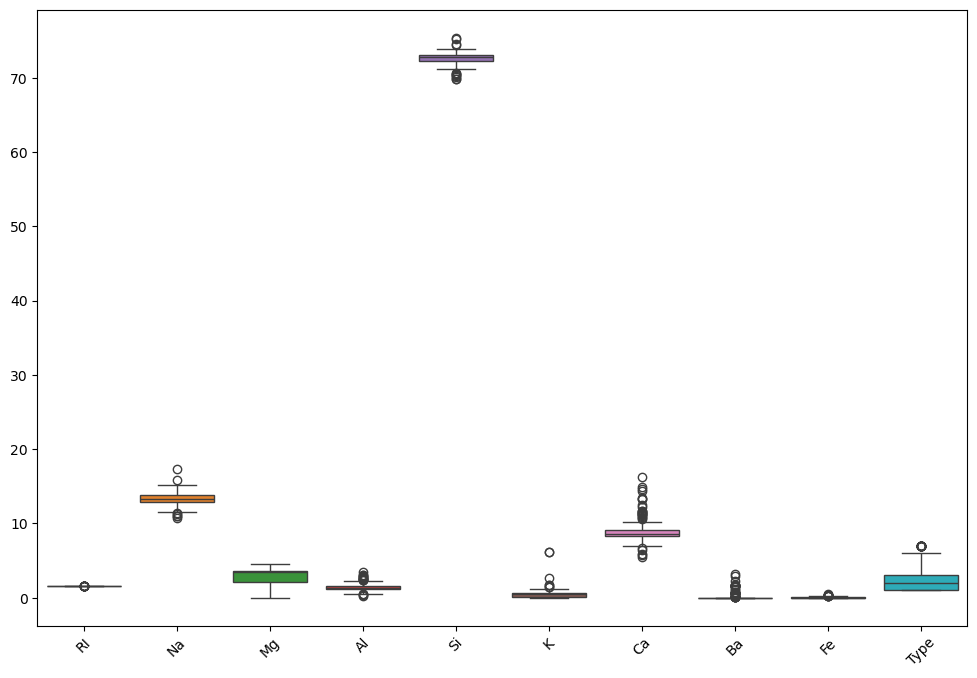

In [9]:
#Check outlier
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

In [10]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))

# Apply capping to all numeric columns
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    cap_outliers(df, col)

print("Outliers capped successfully!")

Outliers capped successfully!


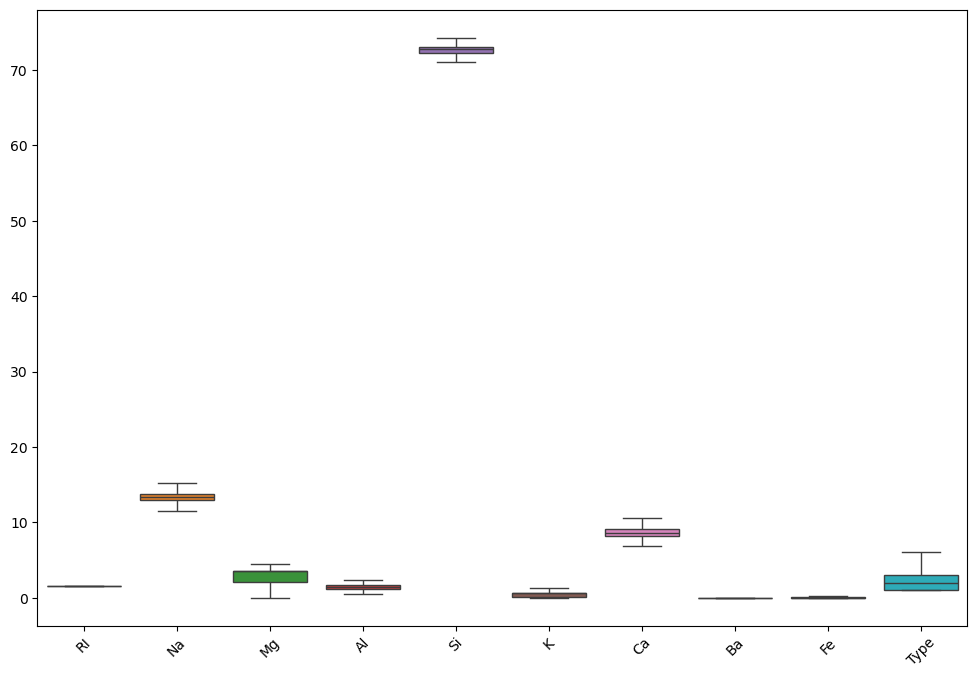

In [11]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

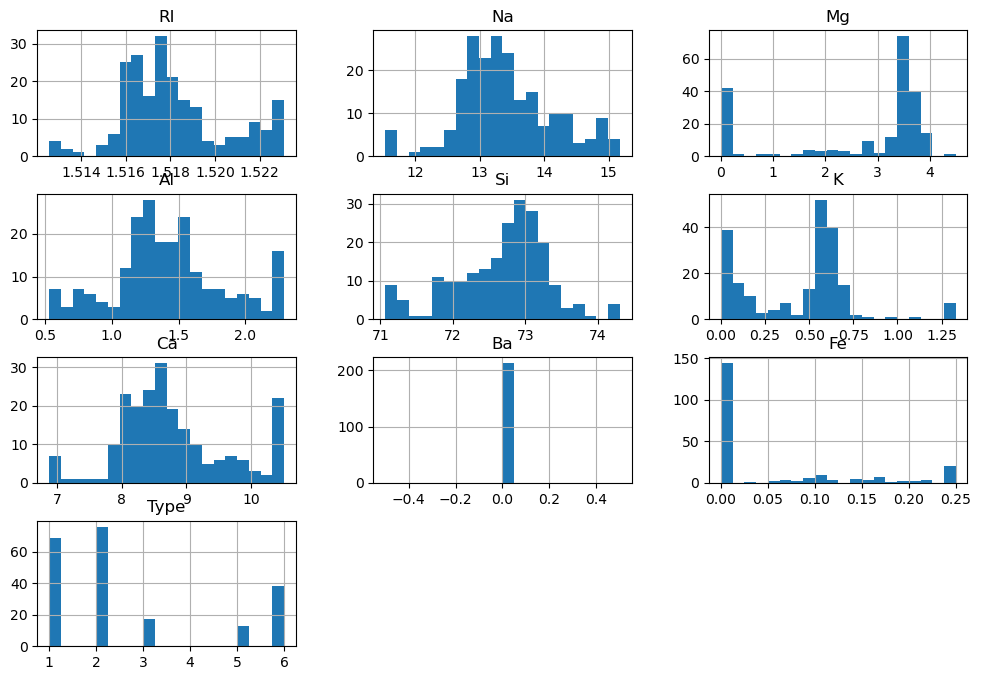

In [12]:
# heatmap plot
df.hist(figsize=(12,8), bins=20)
plt.show()

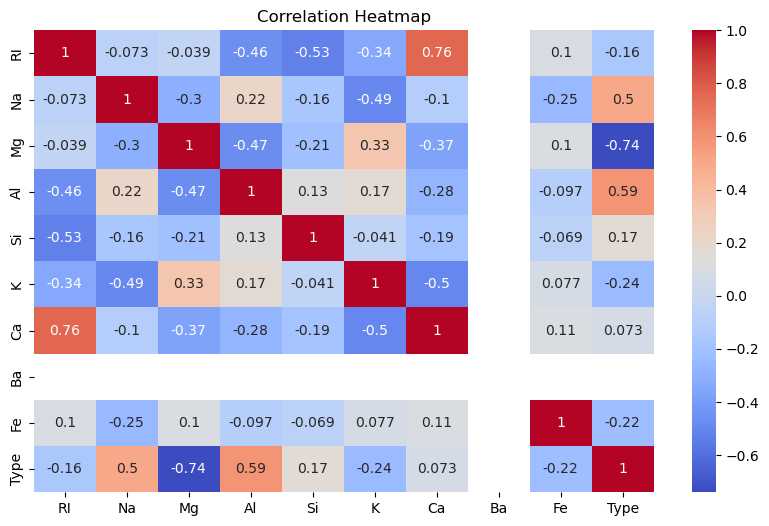

In [13]:
# correlation direction
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
cat_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
# Standerscaler
scaler = StandardScaler()
scaled = scaler.fit_transform(df.drop("Type", axis=1))

X = pd.DataFrame(scaled, columns=df.drop("Type", axis=1).columns)
y = df["Type"]

In [16]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [18]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [19]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.813953488372093

Classification Report:
               precision    recall  f1-score   support

         1.0       0.77      1.00      0.87        10
         2.0       0.75      0.80      0.77        15
         3.0       1.00      0.33      0.50         3
         5.0       0.75      1.00      0.86         3
         6.0       1.00      0.75      0.86        12

    accuracy                           0.81        43
   macro avg       0.85      0.78      0.77        43
weighted avg       0.84      0.81      0.81        43



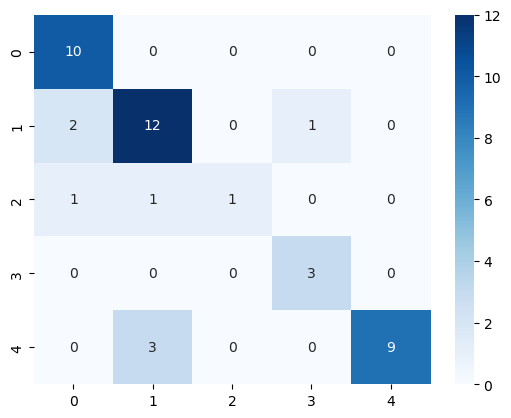

In [21]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.show()

In [22]:
bag = BaggingClassifier(
    estimator=RandomForestClassifier(),
    n_estimators=100,
    random_state=42
)

bag.fit(X_train, y_train)
bag_pred = bag.predict(X_test)

print("Bagging Accuracy =", accuracy_score(y_test, bag_pred))

Bagging Accuracy = 0.8604651162790697


In [23]:
from sklearn.ensemble import AdaBoostClassifier

boost = AdaBoostClassifier(n_estimators=200, random_state=42)

boost.fit(X_train, y_train)
boost_pred = boost.predict(X_test)

print("Boosting Accuracy =", accuracy_score(y_test, boost_pred))

Boosting Accuracy = 0.6744186046511628


Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.
2. Explain how to handle imbalance in the data.

1. Bagging and Boosting – Explanation + Difference
 
 Bagging (Bootstrap Aggregating)

Bagging ek ensemble technique hai jisme hum:

Same algorithm ke multiple models banate hain

Har model ko random subset of data diya jata hai (with replacement → bootstrap)

Sab models apni prediction dete hain

Final output = majority vote (classification) / average (regression)

 Example:
 
Random Forest = Bagging

Har tree ko data ka different random sample milta hai

 Why Bagging?
 
Variance kam karta hai

Overfitting ko control karta hai

Stable predictions deta hai
 Boosting

Boosting me models sequentially banaye jate hain:

Pehla model train hota hai

Jaha wo galti karta hai, next model us galti ko sudharne ki koshish karta hai

Models ek dusre ko improve karte hain

Final result = weighted voting

 Example:
 
AdaBoost

Gradient Boosting

XGBoost

LightGBM

CatBoost

 Why Boosting?
 
Accuracy bahut high deta hai

Bias reduce karta hai

Difficult datasets me best performance

| Feature             | Bagging          | Boosting                               |
| ------------------- | ---------------- | -------------------------------------- |
| Model Training      | Parallel         | Sequential                             |
| Purpose             | Reduce variance  | Reduce bias                            |
| Handles Overfitting | Yes              | Sometimes may overfit                  |
| Error Handling      | All models equal | Next model learns from previous errors |
| Speed               | Faster           | Slower                                 |
| Example             | Random Forest    | AdaBoost, XGBoost, GBoost              |



2.
Imbalanced dataset = jab target class me samples uneven hote hain.

Example:

Class 0 = 90%

Class 1 = 10%

Machine learning model majority class ki taraf bias ho jata hai → accuracy high but performance poor.